# **GROUP 2 - DSS 740 FINAL PROJECT**

**Group 2:** Samantha Skutnik, David Scott, Thomas Higley, and Jacob Chatten

This project aims to give each student an opportunity to understand how an end-to-end ML project is carried out. Each team will have the opportunity to select a meaningful project to work on. By applying various data pre-processing and machine learning steps, students will be able to build a robust solution consisting of a tuned model.

I am here to help. Feel free to schedule a time with me or email me if you want to discuss ideas or need help. Remember, the objective of this course is to ensure you learn and be successful.

Project Requirements:

1. **Project proposal:** Share a proposal (1 page) in an email by April 12th, 2026. The proposal must describe the project's real-world usefulness (business case) and the technical complexity of solving it. The chosen dataset must have at least 1000 rows and 10 columns. Don't be afraid to select a dataset that contains more data.
2. **Data collection and preprocessing**
    1. Data cleaning (data imputation, outlier treatment, and removing duplicates).
    2. Feature engineering.
    3. Exploratory data analysis to identify interesting patterns and decisions made thereafter.
3. **Model development**
    1. Build and compare several candidate models, such as
        1. **Naive Bayes.**
        2. **Logistic Regression.**
        3. **Decision Tree.**
        4. SVM (Kernel Trick).
        5. RandomForest
        6. XGBoost
    2. Perform hyper-parameter tuning (either using Grid Search or RandomizedSearch CV).
    3. Justify model selection using evaluation metrics (accuracy, precision, recall, F1-score, AUC/ROC).
    4. Address class imbalance.
4. Model interpretation and business insights
    1. Use Partial Dependency Plots or SHAP to explain which factors contribute most to the outcome.


**Deliverables**

1. A well-documented Python class and a Jupyter notebook file with clear and logical steps and outcomes.
2. Technical report (5 - 7 pages)
    1. Problem statement and business case
    2. Data preprocessing steps and actions
    3. Model tuning, selection, and justification
    4. Results and insights
    5. Business implications

In [3]:
# Final Project - Group 2

# install the requirements to get all the packages by typing the following in terminal:
# pip install -r requirements.txt 

# If this doesn't work, check Python version (3.11 or 3.12 normally works best I found) OR
# Just install individual packages: pip install missingno

# Installing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import shap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from shap import TreeExplainer, LinearExplainer

## **Initial Import to Add Features to Dataset**

In [4]:
# # identify folder path
# folder_path = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data'

# identify folder path V2 - relative path
# folder_path = r'..\data'

In [5]:
# # combine yearly datasets into one
# dfs = []

# for root, dirs, files in os.walk(folder_path):
#     for filename in files:
#         file_path = os.path.join(root, filename)
#         if filename.endswith(".xlsx"):
#             print(file_path)
#             df_raw = pd.read_excel(file_path)
#             df_raw['Source'] = filename
#             df_raw['Filepath'] = file_path

#             dfs.append(df_raw)

# df_all = pd.concat(dfs, ignore_index = True)

In [6]:
#df_all.info()

In [7]:
# export to excel
# output = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data\all_incidents_combined.xlsx'
# df_all.to_excel(output, index = False, freeze_panes = (1,0))

## **Load and Explore Dataset**

In [8]:
# Load the data if on mac the "\" should be "/"

file = r"../data/all_incidents_combined.xlsx"
df_original = pd.read_excel(file)
df_original.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath
0,NaN,32953,NaN,38492237,18,2,2023-06-07 04:00:00+00,2023-06-07,00:00:00,14.0,202318031155,0 BLOCK IRVING ST,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
1,NaN,32954,NaN,38492238,22,4,2023-07-09 04:00:00+00,2023-07-09,00:00:00,18.0,202322039352,2200 BLOCK CECIL B MOORE A,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 04:00:00+00,2023-04-25,00:00:00,4.0,197935065350,2000 BLOCK 65TH AV,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 05:00:00+00,2023-01-19,00:00:00,20.0,202302002459,1600 BLOCK LEVICK ST,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 04:00:00+00,2023-07-26,00:00:00,19.0,202317020424,900 BLOCK S 17TH ST,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...


In [9]:
# can prob delete this since its a few blocks below too
df_original.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481960.0,2326636.245857,1.0,160223.75,3287768.5,3408717.25,3529207.0,1475288.281407
objectid,481960.0,18196272.352347,96.0,8569044.75,17866839.0,28010682.25,38498485.0,10895389.405756
dc_dist,481960.0,17.454619,1.0,9.0,16.0,24.0,77.0,11.047697
dispatch_date,481960,2024-06-20 11:15:33.567931136,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381341.0,13.112464,0.0,9.0,13.0,17.0,23.0,5.68681
dc_key,481960.0,203253304431.106354,197935065350.0,202324002020.75,202415054325.5,202509022347.75,202503028015001.0,412015870727.550293
ucr_general,481960.0,974.754751,100.0,600.0,700.0,1100.0,2600.0,628.356818
point_x,464528.0,1889.869678,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.009472
point_y,464528.0,223.970884,0.0,39.958716,39.993153,40.03066,301244.661214,6833.493835
lat,464513.0,39.993612,0.0,39.958687,39.993105,40.030598,42.224336,0.216662


In [10]:
# can prob delete this since its a few blocks below too
df_original.describe(include='object').T

,count,unique,top,freq
the_geom,464630,231560,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464513,231528,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_date_time,481960,394896,2023-12-09 00:49:00+00,15
dispatch_time,481960,2039,00:00:00,1132
location_block,481888,63365,5500 BLOCK TULIP ST,1769
text_general_code,481960,32,Thefts,114365
Source,481960,3,2023 incidents_use.xlsx,169017
Filepath,481960,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169017


### **Initial Cleaning/Encoding Raw Data**

More Encoding/Preprocessing Later

In [11]:
# Create a copy of the original data frame to work with for preprocessing
df_cleaned1 = df_original.copy(deep = True)

In [12]:

df_cleaned1['dc_dist'].value_counts()

dc_dist
15    38374
22    34502
9     32677
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
6      9531
5      7459
77     3104
4         1
Name: count, dtype: int64

In [13]:
# Clean Up District Variable

# Replace a specific district value: change all 6s to 9s
df_cleaned1['dc_dist'] = df_cleaned1['dc_dist'].replace(6, 9)
# https://www.nbcphiladelphia.com/news/local/philadelphia-police-to-merge-6th-and-9th-districts/3846335/#:~:text=The%20Philadelphia%20Police%20Department%20merged%20its%206th,more%20efficiently**%20*%20**Proactively%20police%20high%2Dcrime%20areas**


# Drop rows where district is 4
df = df_cleaned1[df_cleaned1['dc_dist'] != 4]
# https://www.phillypolice.com/district/districts-list/

df_cleaned1['dc_dist'].value_counts()

dc_dist
9     42208
15    38374
22    34502
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
5      7459
77     3104
4         1
Name: count, dtype: int64

In [14]:
# examine data types
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  object        
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [15]:
# make dispatch_date_time a date format & convert from UTC to Eastern tz b/c Philly dataset
df_cleaned1['dispatch_date_time'] = pd.to_datetime(df_cleaned1['dispatch_date_time'], utc= True)

df_cleaned1['dispatch_date_time'] = df_cleaned1['dispatch_date_time'].dt.tz_convert("America/New_York")

df_cleaned1['dispatch_date_time'] = df_cleaned1['dispatch_date_time'].dt.tz_convert("America/New_York").dt.tz_localize(None)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  object        
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

In [16]:
# create month col
df_cleaned1['month'] = df_cleaned1['dispatch_date_time'].dt.month

# create day of week col
# 0 = Mon, 1 = Tues, 2 = Wed, 3 = Thurs, 4 = Fri, 5 = Sat, 6 = Sun       - - -    so 5 and 6 would be considered weekends
df_cleaned1['day_of_week'] = df_cleaned1['dispatch_date_time'].dt.dayofweek
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2


In [17]:
# create season col
df_cleaned1['season'] = df_cleaned1['month'].map({
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall", 
})
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer


In [18]:
# create weekday/weekend col
df_cleaned1['week_type'] = df_cleaned1['day_of_week'].map({
    0: "Weekday", 1: "Weekday", 2: "Weekday", 3: "Weekday", 4: "Weekday",
    5: "Weekend", 6: "Weekend"
})
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season,week_type
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer,Weekday
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer,Weekend
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring,Weekday
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer,Weekday


In [19]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [20]:
# look at stats
df_cleaned1.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481960.0,2326636.245857,1.0,160223.75,3287768.5,3408717.25,3529207.0,1475288.281407
objectid,481960.0,18196272.352347,96.0,8569044.75,17866839.0,28010682.25,38498485.0,10895389.405756
dc_dist,481960.0,17.513945,1.0,9.0,16.0,24.0,77.0,10.99395
dispatch_date_time,481960,2024-06-21 00:48:54.207473664,2022-12-31 19:05:00,2023-09-12 15:48:45,2024-06-17 16:58:30,2025-03-29 14:40:00,2025-12-31 18:58:00,NaN
dispatch_date,481960,2024-06-20 11:15:33.567931136,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381341.0,13.112464,0.0,9.0,13.0,17.0,23.0,5.68681
dc_key,481960.0,203253304431.106354,197935065350.0,202324002020.75,202415054325.5,202509022347.75,202503028015001.0,412015870727.550293
ucr_general,481960.0,974.754751,100.0,600.0,700.0,1100.0,2600.0,628.356818
point_x,464528.0,1889.869678,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.009472
point_y,464528.0,223.970884,0.0,39.958716,39.993153,40.03066,301244.661214,6833.493835


In [21]:
df_cleaned1.describe(include = 'object').T

,count,unique,top,freq
the_geom,464630,231560,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464513,231528,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_time,481960,2039,00:00:00,1132
location_block,481888,63365,5500 BLOCK TULIP ST,1769
text_general_code,481960,32,Thefts,114365
Source,481960,3,2023 incidents_use.xlsx,169017
Filepath,481960,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169017
season,481960,4,Summer,132304
week_type,481960,2,Weekday,362699


In [22]:
df_cleaned1['text_general_code'].value_counts()

text_general_code
Thefts                                     114365
Other Assaults                              80021
Motor Vehicle Theft                         51747
Vandalism/Criminal Mischief                 44110
All Other Offenses                          44083
Theft from Vehicle                          33607
Fraud                                       25282
Aggravated Assault No Firearm               16152
Burglary Residential                        10384
Aggravated Assault Firearm                   8380
Weapon Violations                            8247
Narcotic / Drug Law Violations               8017
Robbery No Firearm                           7531
Robbery Firearm                              5533
Burglary Non-Residential                     4823
Receiving Stolen Property                    3929
Other Sex Offenses (Not Commercialized)      3309
DRIVING UNDER THE INFLUENCE                  2566
Arson                                        1988
Disorderly Conduct              

<Axes: ylabel='text_general_code'>

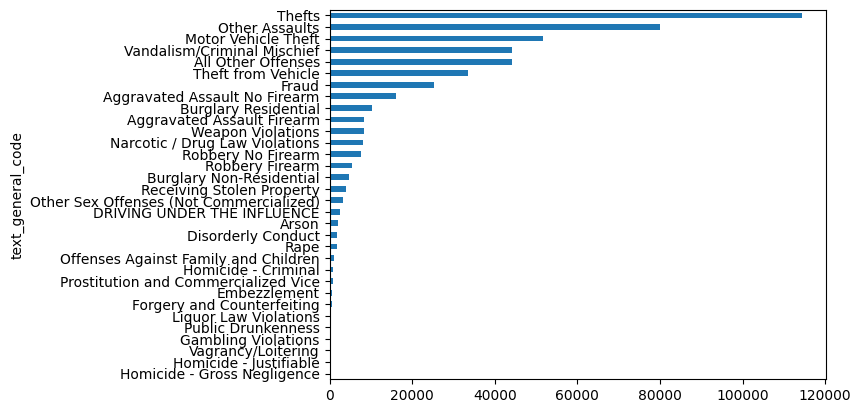

In [23]:
# look at crime type distribution
df_cleaned1['text_general_code'].value_counts().sort_values(ascending = True).plot(kind = 'barh')

array([[<Axes: title={'center': 'cartodb_id'}>,
        <Axes: title={'center': 'objectid'}>,
        <Axes: title={'center': 'dc_dist'}>,
        <Axes: title={'center': 'dispatch_date_time'}>],
       [<Axes: title={'center': 'dispatch_date'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'dc_key'}>,
        <Axes: title={'center': 'ucr_general'}>],
       [<Axes: title={'center': 'point_x'}>,
        <Axes: title={'center': 'point_y'}>,
        <Axes: title={'center': 'lat'}>, <Axes: title={'center': 'lng'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day_of_week'}>, <Axes: >, <Axes: >]],
      dtype=object)

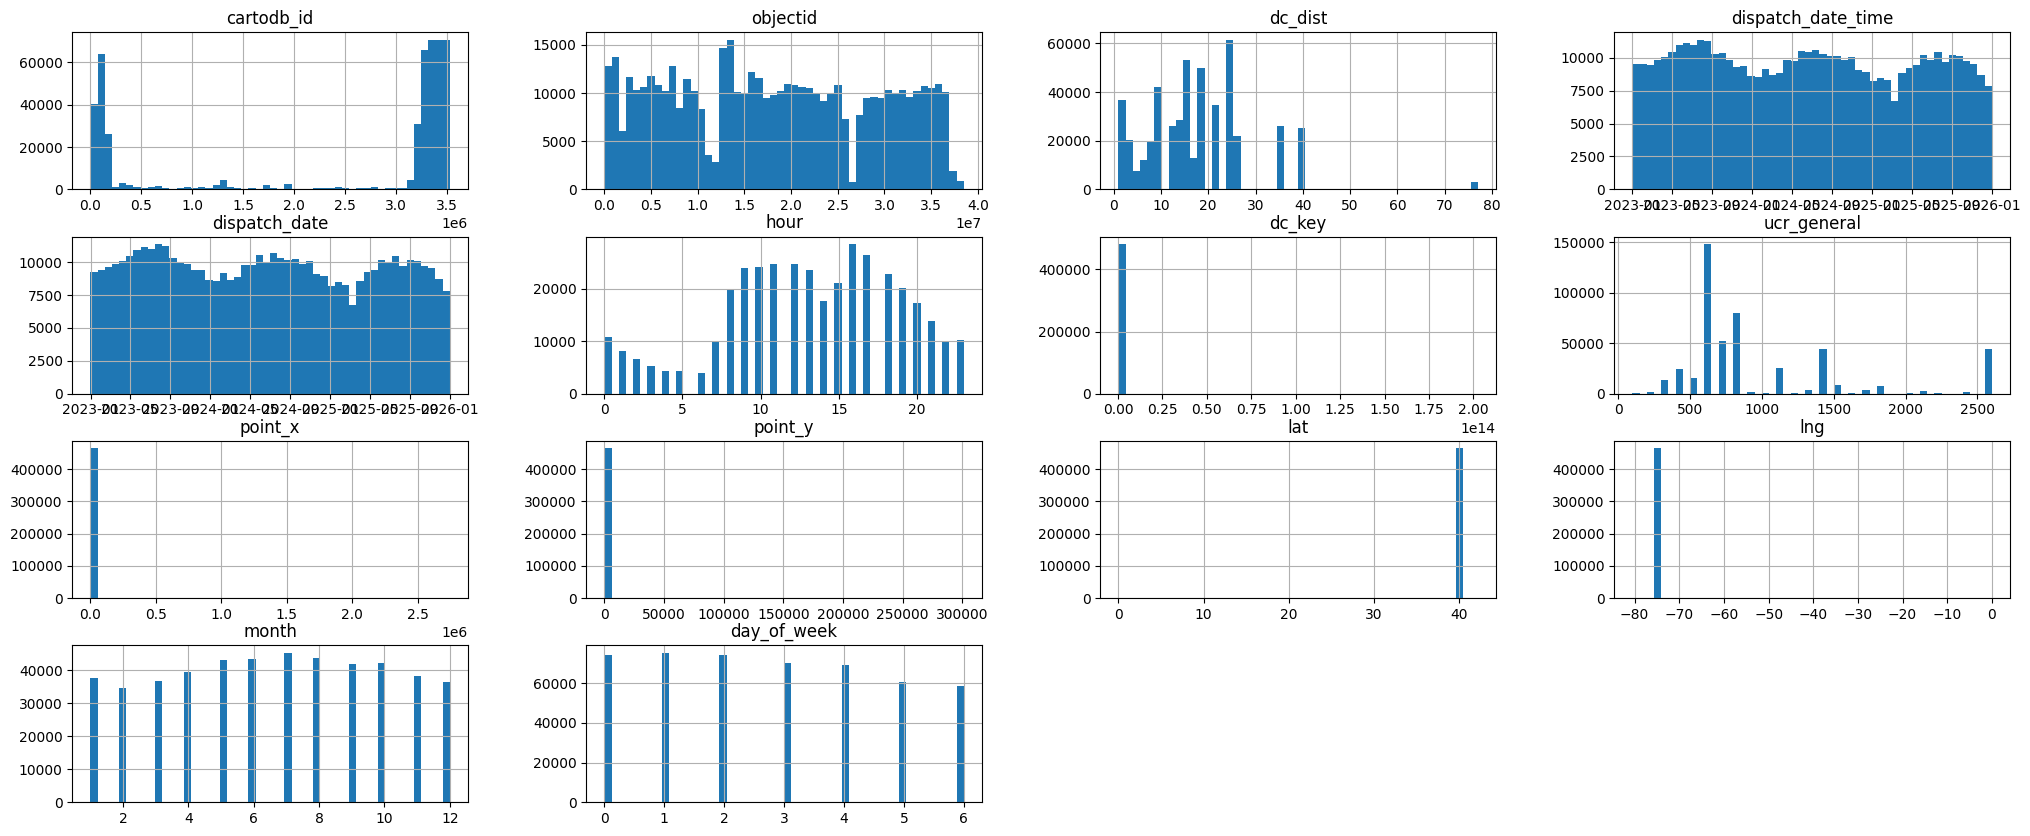

In [24]:
df_cleaned1.hist(bins = 50, figsize = (25, 10))

In [25]:
# classify crime types as violent or not and map text_general_codes
df_cleaned1['text_general_code'] = df_cleaned1['text_general_code'].str.lower().str.strip()

crime_mapping = {
    key.lower(): value for key, value in {
"Aggravated Assault Firearm":1,
"Aggravated Assault No Firearm":1,
"All Other Offenses":0,
"Arson":1,
"Burglary Non-Residential":1,
"Burglary Residential":1,
"Disorderly Conduct":0,
"DRIVING UNDER THE INFLUENCE":0,
"Embezzlement":0,
"Forgery and Counterfeiting":0,
"Fraud":0,
"Gambling Violations":0,
"Homicide - Criminal":1,
"Homicide - Gross Negligence":1,
"Homicide - Justifiable":1,
"Liquor Law Violations":0,
"Motor Vehicle Theft":0,
"Narcotic / Drug Law Violations":0,
"Offenses Against Family and Children":1,
"Other Assaults":1,
"Other Sex Offenses (Not Commercialized)":1,
"Prostitution and Commercialized Vice":0,
"Public Drunkenness":0,
"Rape":1,
"Receiving Stolen Property":0,
"Robbery Firearm":1,
"Robbery No Firearm":1,
"Theft from Vehicle":0,
"Thefts":0,
"Vagrancy/Loitering":0,
"Vandalism/Criminal Mischief":0,
"Weapon Violations":0,
}.items()}

df_cleaned1['violent_crime'] = df_cleaned1['text_general_code'].map(crime_mapping)
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_y,lat,lng,Source,Filepath,month,day_of_week,season,week_type,violent_crime
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer,Weekday,1
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer,Weekend,1
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring,Weekday,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday,1
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer,Weekday,1


In [26]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [27]:
df_cleaned1.isnull().sum().sort_values(ascending = False)

hour                    100619
lat                      17447
lng                      17447
the_geom_webmercator     17447
point_x                  17432
point_y                  17432
the_geom                 17330
psa                        129
location_block              72
dispatch_time                0
dispatch_date                0
dispatch_date_time           0
dc_dist                      0
cartodb_id                   0
objectid                     0
ucr_general                  0
dc_key                       0
text_general_code            0
Source                       0
Filepath                     0
month                        0
day_of_week                  0
season                       0
week_type                    0
violent_crime                0
dtype: int64

In [28]:
# Drop unnecessary cols

df_cleaned1 = df_cleaned1.drop(columns=['hour','the_geom_webmercator', 'lng', 'lat', 'point_x', 'point_y', 'the_geom', 'psa', 'cartodb_id','objectid', 'dc_key', 
                      'dispatch_time', 'dispatch_date', 'Source', 'Filepath', 'location_block' ])

In [29]:
df_cleaned1.isnull().sum().sort_values(ascending = False)

dc_dist               0
dispatch_date_time    0
ucr_general           0
text_general_code     0
month                 0
day_of_week           0
season                0
week_type             0
violent_crime         0
dtype: int64

In [30]:
# Create New Copy / Next Step 
df2 = df_cleaned1.copy(deep = True)

In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   dc_dist             481960 non-null  int64         
 1   dispatch_date_time  481960 non-null  datetime64[ns]
 2   ucr_general         481960 non-null  int64         
 3   text_general_code   481960 non-null  object        
 4   month               481960 non-null  int32         
 5   day_of_week         481960 non-null  int32         
 6   season              481960 non-null  object        
 7   week_type           481960 non-null  object        
 8   violent_crime       481960 non-null  int64         
dtypes: datetime64[ns](1), int32(2), int64(3), object(3)
memory usage: 29.4+ MB


## **Aggregate Predictors and Create Response Variable for High Crime**


In [32]:
 # 1. Check that d
df2['dispatch_date_time'] = pd.to_datetime(df2['dispatch_date_time'])
 
 
# 2. Add Features 'Year' and 'time_of_day
df2['year'] = df2['dispatch_date_time'].dt.year
 
# Bin the hour into four buckets since crime patterns are non-linear across hours
df2['time_of_day'] = df2['dispatch_date_time'].dt.hour.map(
    lambda h: 'Morning'   if 6  <= h < 12
    else      'Afternoon' if 12 <= h < 17
    else      'Evening'   if 17 <= h < 21
    else      'Night'
)
 

# ── 3. NORMALIZE FOR TIME BIAS ───────────────────────────────────────────────
# Two sources of unevenness we correct for:
#   1. Uneven days: a summer weekend has a different number of days than
#      a winter weekday — we count the actual unique days per combination
#      rather than dividing by season and week_type separately, which would
#      over-normalize by multiplying the denominators together unfairly
#   2. Uneven hours: Night (9hrs) vs Evening (4hrs) etc.
# Final rate = crimes per day per hour — fair comparison across all groups
 
# Count actual unique days per year + season + week_type combination
# This avoids over-normalization by counting the exact days that overlap
 
# Count unique dates per year, season, week_type (how many actual Weekdays vs Weekend days)
day_counts = (
    df2.groupby(['year', 'season', 'week_type'])['dispatch_date_time']
    .apply(lambda x: x.dt.date.nunique())
    .reset_index(name='num_days')
)
 
# Fixed hours per time_of_day bucket
time_of_day_hours = {
    'Morning':   6,   # 6am–11am
    'Afternoon': 5,   # 12pm–4pm
    'Evening':   4,   # 5pm–8pm
    'Night':     9    # 9pm–5am
}
 
# ── 4. AGGREGATE INTO ONE ROW PER SCENARIO ───────────────────────────────────
# Each row represents a unique combination of conditions
# e.g. District 3 + Summer + Weekend + Evening + 2022 → crime count
 
# Total crime count per scenario
aggregated = (
    df2.groupby(['dc_dist', 'year', 'season', 'week_type', 'time_of_day'])
    .size()
    .reset_index(name='crime_count')
)
 
# Merge in the actual day counts per year + season + week_type combo
aggregated = aggregated.merge(day_counts, on=['year', 'season', 'week_type'], how='left')
 
# Map in the number of hours per time_of_day bucket
aggregated['num_hours'] = aggregated['time_of_day'].map(time_of_day_hours)
 
# Compute crimes per day per hour — normalized fairly across all groups
aggregated['crime_rate'] = (
    aggregated['crime_count'] / aggregated['num_days'] / aggregated['num_hours']
)

# Original Violent crime rate - removed because data leakage (calcualting with same crimes used to build the label)
 
# Proportion of violent crimes per scenario
# (mean of 0s and 1s gives the rate, e.g. 0.4 = 40% of crimes were violent)
#violent = (
#    df2.groupby(['dc_dist', 'year', 'season', 'week_type', 'time_of_day'])['violent_crime']
#    .mean()
#    .reset_index(name='violent_crime_rate')
#)
 
# Merge violent crime rate into the aggregated dataset
#aggregated = aggregated.merge(
#    violent, on=['dc_dist', 'year', 'season', 'week_type', 'time_of_day']
#)
 
# Merge in day counts for normalization
#aggregated = aggregated.merge(week_type_day_counts, on='week_type')
#aggregated = aggregated.merge(season_day_counts, on='season')
 
# Map in the number of hours per time_of_day bucket
#aggregated['num_hours'] = aggregated['time_of_day'].map(time_of_day_hours)
 
# Compute crimes per day per hour — normalized fairly across all groups
#aggregated['crime_rate'] = (
#    aggregated['crime_count'] / aggregated['num_days_season'] / aggregated['num_days_week_type'] / aggregated['num_hours']
#)
 
 
# ── 5. CREATE THE BINARY RESPONSE VARIABLE ───────────────────────────────────
# Top 25% of crime rates → 1 (High Crime)
# Bottom 75%             → 0 (Low Crime)
# NOTE: This creates a class imbalance (75% Low, 25% High). Use F1-score
# or AUC to evaluate models — not plain accuracy — since a model that always
# predicts Low Crime would still be "75% accurate" without learning anything.
 
threshold = aggregated['crime_rate'].quantile(0.75)
 
aggregated['crime_label'] = aggregated['crime_rate'].apply(
    lambda x: 1 if x >= threshold else 0
)
 
print(f"Threshold (75th percentile crime rate): {threshold:.5f}")
print(f"High Crime rows: {aggregated['crime_label'].sum()}")
print(f"Low Crime rows:  {(aggregated['crime_label'] == 0).sum()}")
 
 
# ── 6. PREPARE FINAL DATASET FOR MODELING ────────────────────────────────────
# Drop intermediate count/rate columns — the model only needs features + label.
# Keeping crime_count or crime_rate would be "cheating" since the label
# was derived directly from them.
 
model_df2 = aggregated[[
    'dc_dist', 'year', 'season', 'week_type', 'time_of_day', 'crime_label'
]].copy()
 
# X = feature columns (inputs to the model)
X = model_df2[['dc_dist', 'year', 'season', 'week_type', 'time_of_day']]
 
# y = response variable (what the model learns to predict)
y = model_df2['crime_label']
 
print("\nFinal dataset sample:")
print(model_df2.head(10))


Threshold (75th percentile crime rate): 1.27160
High Crime rows: 513
Low Crime rows:  1536

Final dataset sample:
   dc_dist  year  season week_type time_of_day  crime_label
0        1  2022  Winter   Weekend       Night            0
1        1  2023    Fall   Weekday   Afternoon            0
2        1  2023    Fall   Weekday     Evening            0
3        1  2023    Fall   Weekday     Morning            0
4        1  2023    Fall   Weekday       Night            0
5        1  2023    Fall   Weekend   Afternoon            0
6        1  2023    Fall   Weekend     Evening            0
7        1  2023    Fall   Weekend     Morning            0
8        1  2023    Fall   Weekend       Night            0
9        1  2023  Spring   Weekday   Afternoon            0


In [33]:
model_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049 entries, 0 to 2048
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   dc_dist      2049 non-null   int64 
 1   year         2049 non-null   int32 
 2   season       2049 non-null   object
 3   week_type    2049 non-null   object
 4   time_of_day  2049 non-null   object
 5   crime_label  2049 non-null   int64 
dtypes: int32(1), int64(2), object(3)
memory usage: 88.2+ KB


# **Model Creation & Training: Logistic Regression, Decision Tree, and XGBoost**

In [34]:
# 1. Create dummy variables (0/1)
model_df3 = pd.get_dummies(
    model_df2,
    columns=['dc_dist', 'year', 'season', 'week_type', 'time_of_day'],
    drop_first=True,
    dtype=int
)

# 2. Define X and y
X = model_df3.drop(columns=['crime_label'])
y = model_df3['crime_label']

# 3. Train/Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3.5 Scale Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)   # no fit_ to avoid data leakage

In [35]:
model_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049 entries, 0 to 2048
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   crime_label          2049 non-null   int64
 1   dc_dist_2            2049 non-null   int64
 2   dc_dist_3            2049 non-null   int64
 3   dc_dist_4            2049 non-null   int64
 4   dc_dist_5            2049 non-null   int64
 5   dc_dist_7            2049 non-null   int64
 6   dc_dist_8            2049 non-null   int64
 7   dc_dist_9            2049 non-null   int64
 8   dc_dist_12           2049 non-null   int64
 9   dc_dist_14           2049 non-null   int64
 10  dc_dist_15           2049 non-null   int64
 11  dc_dist_16           2049 non-null   int64
 12  dc_dist_17           2049 non-null   int64
 13  dc_dist_18           2049 non-null   int64
 14  dc_dist_19           2049 non-null   int64
 15  dc_dist_22           2049 non-null   int64
 16  dc_dist_24           204

In [36]:
# Logistic Regression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nLogistic Regression Coefficients:")
print(coef_df)

Accuracy: 0.9268
Precision: 0.8011
Recall: 0.9416
F1 Score: 0.8657
AUC: 0.9802

Confusion Matrix:
[[425  36]
 [  9 145]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       461
           1       0.80      0.94      0.87       154

    accuracy                           0.93       615
   macro avg       0.89      0.93      0.91       615
weighted avg       0.93      0.93      0.93       615


Logistic Regression Coefficients:
                Feature  Coefficient
30    time_of_day_Night    -4.338272
9            dc_dist_15     2.045964
6             dc_dist_9     2.021329
27    week_type_Weekend    -1.620248
14           dc_dist_22     1.476700
13           dc_dist_19     1.324932
15           dc_dist_24     1.314909
29  time_of_day_Morning    -1.198527
21            year_2023     1.149475
8            dc_dist_14     1.108410
16           dc_dist_25     1.069404
0             dc_dist_2     1.051386
18          

In [37]:
# Below is the tuned logistic regression model. 
# The output metrics are slightly better
# Accuracy, precision, recall f1 are all slighly better. not by much

# 4. Hyperparameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],              # regularization strength
    'penalty': ['l1', 'l2'],                  # Lasso vs Ridge
    'solver': ['liblinear'],                  # supports both l1 and l2
    'class_weight': [None, 'balanced']
}

# 5. Grid Search - Cross validation with 5 folds, train on 4 folds, validate on 1
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_log = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


y_pred = best_log.predict(X_test_scaled)
y_prob = best_log.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_log.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

Best Parameters: {'C': 100, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.9285
Precision: 0.8618
Recall: 0.8506
F1 Score: 0.8562
AUC: 0.9816

Confusion Matrix:
[[440  21]
 [ 23 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       461
           1       0.86      0.85      0.86       154

    accuracy                           0.93       615
   macro avg       0.91      0.90      0.90       615
weighted avg       0.93      0.93      0.93       615

                Feature  Coefficient
30    time_of_day_Night    -7.639957
21            year_2023     3.806234
9            dc_dist_15     3.534126
6             dc_dist_9     3.409492
22            year_2024     3.365779
23            year_2025     2.995656
14           dc_dist_22     2.611937
13           dc_dist_19     2.422543
15           dc_dist_24     2.343761
16           dc_dist_25     2.139198
8            dc_dist_14     2.1

In [38]:
# Decision Tree - the output metrics are much better in this model

# 4. Fit Decision Tree
tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

tree_model.fit(X_train_scaled, y_train) # Could just use x_train too for decision tree and XGBoost, but will keep scaled to keep consistent

# 5. Predictions
y_pred = tree_model.predict(X_test_scaled)
y_prob = tree_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nDecision Tree Feature Importances:")
print(importance_df)

Accuracy: 0.8862
Precision: 0.7917
Recall: 0.7403
F1 Score: 0.7651
AUC: 0.8376

Confusion Matrix:
[[431  30]
 [ 40 114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       461
           1       0.79      0.74      0.77       154

    accuracy                           0.89       615
   macro avg       0.85      0.84      0.84       615
weighted avg       0.88      0.89      0.88       615


Decision Tree Feature Importances:
                Feature  Importance
30    time_of_day_Night    0.201117
27    week_type_Weekend    0.067436
6             dc_dist_9    0.057055
9            dc_dist_15    0.050767
14           dc_dist_22    0.044744
29  time_of_day_Morning    0.043717
21            year_2023    0.037035
28  time_of_day_Evening    0.036504
26        season_Winter    0.033379
24        season_Spring    0.031402
11           dc_dist_17    0.030857
13           dc_dist_19    0.029370
4             dc_dist_7 

In [39]:
# Tuned Decision Tree - 

# 4. Set up hyperparameter grid 
#  The model look at various specifications, for example: max depth, looks at
# max depth of 3, 5, 7, 10, and no max
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# 5. Run grid search
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

# Best tuned model
best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# 6. Predictions
y_pred = best_tree.predict(X_test_scaled)
y_prob = best_tree.predict_proba(X_test_scaled)[:, 1]

# 7. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTuned Decision Tree Feature Importances:")
print(importance_df)

Best Parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.9187
Precision: 0.8467
Recall: 0.8247
F1 Score: 0.8355
AUC: 0.8874

Confusion Matrix:
[[438  23]
 [ 27 127]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       461
           1       0.85      0.82      0.84       154

    accuracy                           0.92       615
   macro avg       0.89      0.89      0.89       615
weighted avg       0.92      0.92      0.92       615


Tuned Decision Tree Feature Importances:
                Feature  Importance
30    time_of_day_Night    0.151970
29  time_of_day_Morning    0.095805
27    week_type_Weekend    0.067198
6             dc_dist_9    0.063048
9            dc_dist_15    0.062400
26        season_Winter    0.055450
14           dc_dist_22    0.044295
13           dc_dist_19    0.040933
21            year_2023    0.039

In [40]:
from xgboost import XGBClassifier

# XGBoost - you might need to intall xgboost
# in your terminal type "pip install xgboost" without the quotation marks


# 4. Fit XGBoost
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    nthread=1,        # single thread = identical results for all team
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importances:")
print(importance_df)

Accuracy: 0.9317
Precision: 0.9058
Recall: 0.8117
F1 Score: 0.8562
AUC: 0.9774

Confusion Matrix:
[[448  13]
 [ 29 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       461
           1       0.91      0.81      0.86       154

    accuracy                           0.93       615
   macro avg       0.92      0.89      0.91       615
weighted avg       0.93      0.93      0.93       615


XGBoost Feature Importances:
                Feature  Importance
30    time_of_day_Night    0.131327
6             dc_dist_9    0.066441
9            dc_dist_15    0.063823
14           dc_dist_22    0.050741
4             dc_dist_7    0.044968
27    week_type_Weekend    0.043731
3             dc_dist_5    0.043106
11           dc_dist_17    0.041643
15           dc_dist_24    0.040146
13           dc_dist_19    0.039664
20           dc_dist_77    0.039343
16           dc_dist_25    0.037244
10           dc_dist_16    0.0

In [45]:
# Tuned XGBoost

# 4. Handle class imbalance (VERY important)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 5. Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, scale_pos_weight]
}

# 6. Grid Search
grid = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        nthread=1,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

# Best model
best_xgb = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# 7. Predictions
y_pred = best_xgb.predict(X_test_scaled)
y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 8. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTuned XGBoost Feature Importances:")
print(importance_df)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 1.0}
Accuracy: 0.9317
Precision: 0.8944
Recall: 0.8247
F1 Score: 0.8581
AUC: 0.9799

Confusion Matrix:
[[446  15]
 [ 27 127]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       461
           1       0.89      0.82      0.86       154

    accuracy                           0.93       615
   macro avg       0.92      0.90      0.91       615
weighted avg       0.93      0.93      0.93       615


Tuned XGBoost Feature Importances:
                Feature  Importance
30    time_of_day_Night    0.163325
9            dc_dist_15    0.071691
4             dc_dist_7    0.062483
6             dc_dist_9    0.060316
20           dc_dist_77    0.053598
3             dc_dist_5    0.053327
10           dc_dist_16    0.051346
11           dc_dist_17    0.049696
5             dc_dist_8  

In [47]:
# AUC Score, F1 Score, and Recall all important (accuracy could be missleading because of class imbalance)

results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'Accuracy': [0.9268, 0.9285, 0.8862, 0.9187, 0.9317, 0.9317],
    'Precision': [0.8011, 0.8618, 0.7917, 0.8467, 0.9058, 0.8944],
    'Recall': [0.9416, 0.8506, 0.7403, 0.8247, 0.8117, 0.8247],
    'F1 Score': [0.8657, 0.8562, 0.7651, 0.8355, 0.8562, 0.8581],
    'AUC': [0.9802, 0.9816, 0.8376, 0.8874, 0.9774, 0.9799]
})

# Sort by best model (F1 Score)
results_df = results_df.sort_values(by='F1 Score', ascending=False)

print(results_df)

                       Model  Accuracy  Precision  Recall  F1 Score     AUC
0        Logistic Regression    0.9268     0.8011  0.9416    0.8657  0.9802
5              Tuned XGBoost    0.9317     0.8944  0.8247    0.8581  0.9799
1  Tuned Logistic Regression    0.9285     0.8618  0.8506    0.8562  0.9816
4                    XGBoost    0.9317     0.9058  0.8117    0.8562  0.9774
3        Tuned Decision Tree    0.9187     0.8467  0.8247    0.8355  0.8874
2              Decision Tree    0.8862     0.7917  0.7403    0.7651  0.8376


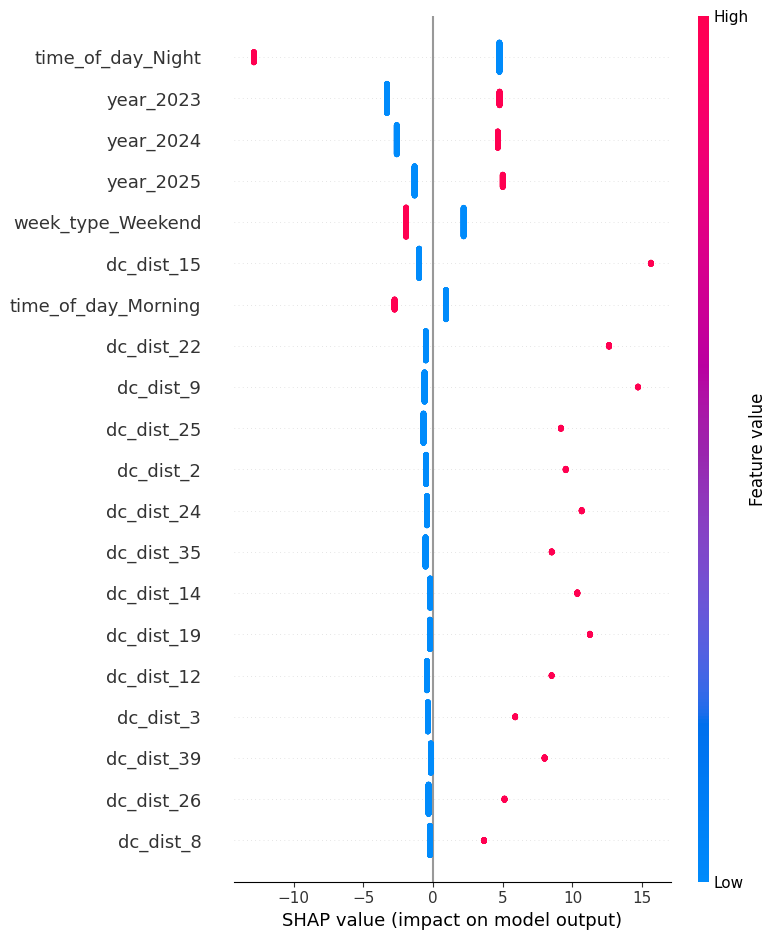

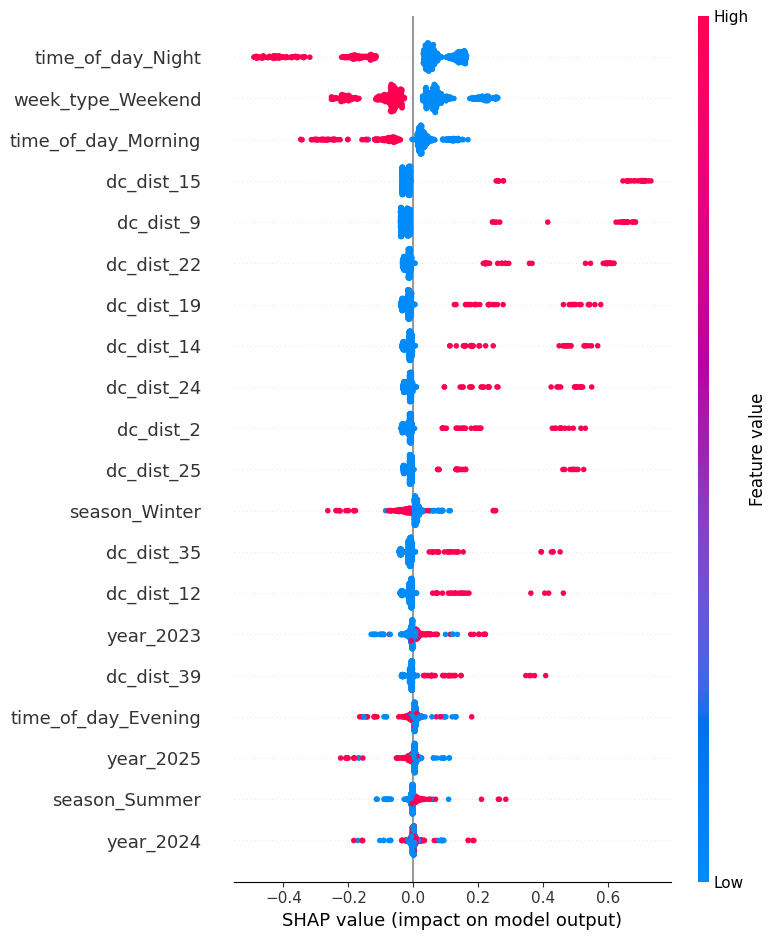

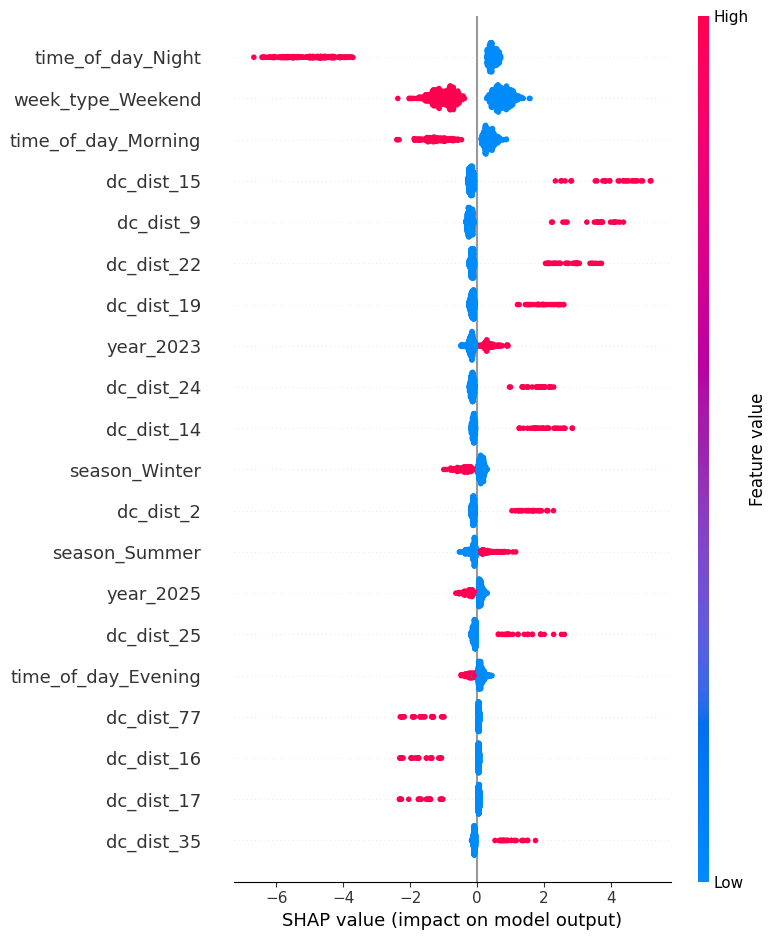

In [46]:
# SHAP Test 

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Logistic Regression
explainer_lr = LinearExplainer(best_log, X_train_scaled_df)
shap_values_lr = explainer_lr.shap_values(X_test_scaled_df)
shap.summary_plot(shap_values_lr, X_test_scaled_df)

# Decision Tree
explainer_dt = TreeExplainer(best_tree)
shap_values_dt = explainer_dt.shap_values(X_test_scaled_df)
shap.summary_plot(shap_values_dt[:, :, 1], X_test_scaled_df)

# XGBoost
explainer_xgb = TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_scaled_df)
shap.summary_plot(shap_values_xgb, X_test_scaled_df)
